In [106]:
import pandas as pd
from great_tables import GT, style, loc
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
from matplotlib.colors import Normalize, LinearSegmentedColormap
import colorsys
from calculate_performance_metrics import compute_metrics
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.utils import resample
from sklearn.metrics import precision_recall_curve, average_precision_score, brier_score_loss

In [107]:
data = pd.read_csv("../../data/test_predictions_valor_pd_final.csv")
data = data[~data['uncertain_indices']]

In [108]:
data_full_sample = data[data['test_split'] == 'full_data']
data_demo_matched = data[data['test_split'] == 'demo_matched']
metrics_full = compute_metrics(data_full_sample['pred_score_fusion'], data_full_sample['true_label'], random_state=42)
metrics_demo = compute_metrics(data_demo_matched['pred_score_fusion'], data_demo_matched['true_label'], random_state=42)

In [109]:
metrics_full

{'accuracy': 0.9290322580645162,
 'average_precision': 0.8225192811141959,
 'roc_auc': 0.9170666666666667,
 'f1_score': 0.8135593220338984,
 'precision': 0.8275862068965517,
 'recall': 0.8,
 'specificity': 0.96,
 'FPR': 0.04,
 'NPV': 0.9523809523809523,
 'weighted_accuracy': 0.88,
 'accuracy_ci': (0.8876, 0.9686),
 'average_precision_ci': (0.6978, 0.9502),
 'roc_auc_ci': (0.8537, 0.9784),
 'f1_score_ci': (0.6956, 0.9224),
 'precision_ci': (0.6838, 0.9696),
 'recall_ci': (0.6503, 0.9444),
 'specificity_ci': (0.9255, 0.9939),
 'FPR_ci': (0.0061, 0.0745),
 'NPV_ci': (0.9135, 0.9893),
 'weighted_accuracy_ci': (0.8028, 0.9543),
 'confusion_matrix': {'tn': 120, 'fp': 5, 'fn': 6, 'tp': 24},
 'formatted_accuracy': '92.90 ± 4.1%',
 'formatted_sensitivity': '80.00 ± 14.7%',
 'formatted_specificity': '96.00 ± 3.4%',
 'formatted_ppv': '82.76 ± 14.3%',
 'formatted_npv': '95.24 ± 3.8%',
 'formatted_f1score': '81.36 ± 11.3%',
 'accuracy_err': 0.040500000000000036,
 'sensitivity_err': 0.14705000000000

In [110]:
metrics_demo

{'accuracy': 0.863013698630137,
 'average_precision': 0.9104416297513661,
 'roc_auc': 0.9233082706766917,
 'f1_score': 0.8648648648648649,
 'precision': 0.8205128205128205,
 'recall': 0.9142857142857143,
 'specificity': 0.8157894736842105,
 'FPR': 0.18421052631578946,
 'NPV': 0.9117647058823529,
 'weighted_accuracy': 0.8650375939849624,
 'accuracy_ci': (0.7826, 0.9436),
 'average_precision_ci': (0.8245, 0.9995),
 'roc_auc_ci': (0.86, 0.9887),
 'f1_score_ci': (0.7777, 0.9491),
 'precision_ci': (0.6957, 0.9422),
 'recall_ci': (0.8254, 1.0076),
 'specificity_ci': (0.6907, 0.9383),
 'FPR_ci': (0.0617, 0.3093),
 'NPV_ci': (0.8175, 1.0094),
 'weighted_accuracy_ci': (0.7864, 0.9446),
 'confusion_matrix': {'tn': 31, 'fp': 7, 'fn': 3, 'tp': 32},
 'formatted_accuracy': '86.30 ± 8.1%',
 'formatted_sensitivity': '91.43 ± 9.1%',
 'formatted_specificity': '81.58 ± 12.4%',
 'formatted_ppv': '82.05 ± 12.3%',
 'formatted_npv': '91.18 ± 9.6%',
 'formatted_f1score': '86.49 ± 8.6%',
 'accuracy_err': 0.080

# Plot Performance Table

In [111]:
def blend_hex(hex_color: str, frac: float, toward_white: bool = True) -> str:
    frac = frac - (frac - 0.5)*0.7
    r, g, b = mcolors.to_rgb(hex_color)
    r2, g2, b2 = (1,1,1) if toward_white else (0,0,0)
    r_new = r2 + (r - r2) * frac
    g_new = g2 + (g - g2) * frac
    b_new = b2 + (b - b2) * frac
    # print(mcolors.to_hex((r_new, g_new, b_new)))
    return mcolors.to_hex((r_new, g_new, b_new))


def create_performance_table(
    data: dict,
    errors: dict,
    base_colors: list,
    cols_width: int = 100,
    vert_padd: int = 2,
    equal_size: bool = False,
    newline: bool = True,
    title: str = "",
    smooth_corners: bool = False,
    font: str = None,
    bold_headers: bool = False,
    no_grid: bool = False,
    rowname_col: str = "Test Set",
    first_col_label: str = "Test Dataset",
    count_pct_bg_color: str = "#F4F4F4",   # used for Sample Size + Prevalence
    divider_color: str = "#D3D3D3",        # row divider color
    count_row_divider_weight: str = "1px",
) -> GT:
    """
    Adds support for both:
      - Sample Size N(%)
      - Prevalence N(%)

    For any column whose name contains (case-insensitive):
      - "sample size" OR
      - "prevalence"

    the function formats as:
        X
        (y%)
    where:
      - X comes from data[col]
      - y comes from errors[col] and may be either:
          * fraction in [0,1]   (e.g., 0.495), OR
          * percent in [0,100]  (e.g., 49.5)
        The function normalizes to percent automatically.

    These count/% columns are excluded from the heatmap and receive:
      - mild fixed background
      - horizontal row dividers (top/bottom) to match stub row separation style
    """

    df = pd.DataFrame(data)
    err_df = pd.DataFrame(errors)

    if rowname_col not in df.columns:
        raise ValueError(f"'{rowname_col}' must be a key/column in `data`.")

    # Count/% columns: Sample Size + Prevalence
    def _is_count_pct_col(c: str) -> bool:
        s = str(c).lower()
        return ("sample size" in s) or ("prevalence" in s)

    count_pct_cols = [c for c in df.columns if _is_count_pct_col(c)]

    # Numeric columns (GT heatmap candidates)
    num_cols = list(df.select_dtypes(include="number").columns)

    # Heatmap columns exclude count/% columns
    heatmap_cols = [c for c in num_cols if c not in count_pct_cols]

    # Build text DataFrame
    text_df = df.copy()
    sep = "\n±" if newline else " ± "

    def _is_all_empty_error(colname: str) -> bool:
        if colname not in err_df.columns:
            return True
        for v in err_df[colname].tolist():
            if v != "" and not pd.isna(v):
                return False
        return True

    def _fmt_intish(x):
        """Format ints without .0; keep floats compact; preserve strings."""
        if pd.isna(x):
            return ""
        try:
            xf = float(x)
            return str(int(xf)) if xf.is_integer() else f"{xf:g}"
        except Exception:
            return str(x)

    def _to_pct(frac_or_pct):
        """Accept either fraction (0..1) or percent (0..100). Return percent."""
        v = float(frac_or_pct)
        return v if v > 1 else v * 100.0

    for col in num_cols:
        # Count/% columns: show X on line 1 and (y%) on line 2
        if col in count_pct_cols:
            if col in err_df.columns:
                out = []
                for x, p in zip(df[col].tolist(), err_df[col].tolist()):
                    x_disp = _fmt_intish(x)
                    if x_disp == "":
                        out.append("")
                        continue
                    if p == "" or pd.isna(p):
                        out.append(x_disp)
                        continue
                    try:
                        pct = _to_pct(p)
                        out.append(f"{x_disp}\n({pct:.1f}%)")
                    except Exception:
                        out.append(x_disp)
                text_df[col] = out
            else:
                text_df[col] = df[col].map(_fmt_intish)
            continue

        # Other numeric columns: raw or mean% ± err%
        if _is_all_empty_error(col):
            text_df[col] = df[col].map(lambda x: "" if pd.isna(x) else f"{x}")
        else:
            mean_pct = (df[col] * 100).map(lambda x: "" if pd.isna(x) else f"{x:.1f}%")
            err_pct  = (err_df[col] * 100).map(lambda x: "" if pd.isna(x) else f"{x:.1f}%")
            text_df[col] = mean_pct + sep + err_pct

    # Quantile-based normalization for heatmap (exclude count/% columns)
    if len(heatmap_cols) > 0:
        num_only = df[heatmap_cols]
        low = num_only.quantile(0.05).min()
        high = num_only.quantile(0.95).max()
        norm = Normalize(vmin=low, vmax=high, clip=True)
    else:
        norm = None

    # Initialize GT
    gt = GT(text_df, rowname_col=rowname_col)
    gt = gt.tab_stubhead(label=first_col_label)

    # Base text styling
    text_style = {"color": "black", "align": "center"}
    if font:
        text_style["font"] = font
    if newline:
        text_style["whitespace"] = "pre-wrap"
    gt = gt.tab_style(style=style.text(**text_style), locations=loc.body())

    # Optional header bolding
    if bold_headers:
        gt = gt.tab_style(style=style.text(weight="bold", align="center"), locations=loc.column_header())
        gt = gt.tab_style(style=style.text(weight="bold", align="center"), locations=loc.stub())

    # Make stubhead bold
    gt = gt.tab_style(
        style=style.text(weight="bold", color="black", size="18px"),
        locations=loc.stubhead()
    )

    # Heatmap fill for metric cells
    if norm is not None:
        for i, base in enumerate(base_colors):
            for col in heatmap_cols:
                val = float(df.at[i, col])
                frac = norm(val)
                cell_hex = blend_hex(base, frac, toward_white=True)
                gt = gt.tab_style(
                    style=style.fill(color=cell_hex),
                    locations=loc.body(rows=[i], columns=[col])
                )

    # Optional no-grid (kept as you had it)
    if no_grid:
        gt = gt.tab_style(style=style.borders(sides="all", color="transparent"), locations=loc.body())

    # Equal column widths
    if equal_size:
        all_cols = [rowname_col] + [c for c in text_df.columns if c != rowname_col]
        gt = gt.cols_width(**{col: f"{cols_width}px" for col in all_cols})

    if smooth_corners:
        pass

    gt = gt.opt_vertical_padding(vert_padd)

    if title:
        gt = gt.tab_header(title=title)

    # Center-align metric columns that exist
    metric_columns = ["Accuracy", "Specificity", "Sensitivity", "PPV", "NPV", "F1 Score"]
    metric_columns_present = [c for c in metric_columns if c in text_df.columns]
    if metric_columns_present:
        gt = gt.cols_align(align="center", columns=metric_columns_present)

    # Count/% columns: center + mild background + row dividers
    if count_pct_cols:
        gt = gt.cols_align(align="center", columns=count_pct_cols)

        gt = gt.tab_style(
            style=style.fill(color=count_pct_bg_color),
            locations=loc.body(columns=count_pct_cols)
        )

        # Horizontal row separators to match stub separation feel
        gt = gt.tab_style(
            style=style.borders(
                sides=["top", "bottom"],
                color=divider_color,
                weight=count_row_divider_weight,
            ),
            locations=loc.body(columns=count_pct_cols)
        )

    # Column labels styling
    gt = gt.tab_style(
        style=style.text(color="black", weight="bold", size="18px", align="center"),
        locations=loc.column_labels()
    )

    # Stub styling (row labels)
    gt = gt.tab_style(
        style=style.text(color="blue", size="18px"),
        locations=loc.stub()
    )

    # Body font size
    gt = gt.tab_style(
        style=style.text(size="18px"),
        locations=loc.body()
    )

    return gt


In [112]:
PREVALENCE_FULL_DATA = data_full_sample['true_label'].sum()
PREVALENCE_DEMO_MATCHED = data_demo_matched['true_label'].sum()

metrics = {
    "Test Set": ["Full Cohort","Demographic Matched Cohort"],
    "Sample Size": [data_full_sample.shape[0], data_demo_matched.shape[0]],
    "Prevalence N(%)": [PREVALENCE_FULL_DATA, PREVALENCE_DEMO_MATCHED],
    "Accuracy": [metrics_full["accuracy"], metrics_demo["accuracy"]],
    "Sensitivity": [metrics_full["recall"], metrics_demo["recall"]],
    "Specificity": [metrics_full["specificity"], metrics_demo["specificity"]],
    "PPV": [metrics_full["precision"], metrics_demo["precision"]],
    "NPV": [metrics_full["NPV"], metrics_demo["NPV"]],
    "F1 Score": [metrics_full["f1_score"], metrics_demo["f1_score"]]
}

errors = {
    "Sensitivity": [metrics_full["sensitivity_err"], metrics_demo["sensitivity_err"]],
    "Sample Size": ["", ""],
    "Prevalence N(%)": [round(PREVALENCE_FULL_DATA/data_full_sample.shape[0]*100,2), round(PREVALENCE_DEMO_MATCHED/data_demo_matched.shape[0]*100,2)],
    "Sensitivity": [metrics_full["sensitivity_err"], metrics_demo["sensitivity_err"]],
    "Specificity": [metrics_full["specificity_err"], metrics_demo["specificity_err"]],
    "PPV": [metrics_full["ppv_err"], metrics_demo["ppv_err"]],
    "NPV": [metrics_full["npv_err"], metrics_demo["npv_err"]],
    "Accuracy": [metrics_full["accuracy_err"], metrics_demo["accuracy_err"]],
    "F1 Score": [metrics_full["f1score_err"], metrics_demo["f1score_err"]]
}
base_colors = ["#633974", "#1a5276"]

gt_table = create_performance_table(
    metrics, errors, base_colors,
    cols_width=130,
    vert_padd=2,
    equal_size=True,
    newline=True,
    # title="Predictive performance of PARK across independent test sets",
    smooth_corners=True,
    font="Roboto, sans-serif",
    bold_headers=False,
    no_grid=True,
    first_col_label="Test Dataset"
)
gt_table.save(file="plots/figure_1/test_sets_performance.png", scale=2)
gt_table.show() 

Test Dataset 
 Sample Size 
 Prevalence N(%) 
 Accuracy 
 Sensitivity 
 Specificity 
 PPV 
 NPV 
 F1 Score 
 
 
 
 
 Full Cohort 
 155 
 30
(19.4%) 
 92.9%
±4.1% 
 80.0%
±14.7% 
 96.0%
±3.4% 
 82.8%
±14.3% 
 95.2%
±3.8% 
 81.4%
±11.3% 
 
 
 Demographic Matched Cohort 
 73 
 35
(48.0%) 
 86.3%
±8.1% 
 91.4%
±9.1% 
 81.6%
±12.4% 
 82.1%
±12.3% 
 91.2%
±9.6% 
 86.5%
±8.6%

# Plot AUROC and AUPRC

In [113]:
def plot_roc_with_ci_ax(
    ax,
    preds,
    labels,
    n_bootstraps=1000,
    seed=None,
    mean_color="#1f77b4",
    chance_color="#7f7f7f",
    ci_color="#c7c7c7",
    ci_alpha=0.2,
    show_legend=True,
):

    if seed is not None:
        np.random.seed(seed)

    # 1) Original ROC & AUC
    fpr, tpr, _ = roc_curve(labels, preds)
    roc_auc = auc(fpr, tpr)

    # 2) Bootstrap TPRs at a common grid
    mean_fpr = np.linspace(0, 1, 200)
    tprs = []
    for _ in range(n_bootstraps):
        idxs = resample(np.arange(len(preds)))
        # skip if only one class present
        if len(np.unique(labels[idxs])) < 2:
            continue
        fpr_b, tpr_b, _ = roc_curve(labels[idxs], preds[idxs])
        tpr_i = np.interp(mean_fpr, fpr_b, tpr_b)
        tpr_i[0] = 0.0
        tprs.append(tpr_i)
    tprs = np.array(tprs)
    b = tprs.shape[0]

    # 3) Compute mean and SE (normal‐approx CI)
    mean_tpr = tprs.mean(axis=0)
    se_tpr   = np.sqrt(((tprs - mean_tpr)**2).sum(axis=0) / (b - 1))
    ci_half  = 1.96 * se_tpr  # for 95%
    lower    = mean_tpr - ci_half
    upper    = mean_tpr + ci_half

    # 4) Plot
    ax.plot(mean_fpr, mean_tpr, color=mean_color, lw=2,
            label=f"Mean (AUC = {roc_auc:.2f})")
    ax.fill_between(mean_fpr, lower, upper,
                    color=ci_color, alpha=ci_alpha,
                    label=f"95% C.I.")
    ax.plot([0, 1], [0, 1], linestyle="--", color=chance_color, lw=1, label="Chance")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate", fontsize=20)
    ax.set_ylabel("True Positive Rate", fontsize=20)
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)
    ax.grid(True, linestyle="--", alpha=0.5)
    if show_legend:
        ax.legend(loc="lower right", fontsize=18)

def plot_multiple_rocs_with_ci(
    preds_list,
    labels_list,
    mean_colors,
    chance_colors,
    ci_colors,
    ci_alpha=0.2,
    n_bootstraps=1000,
    seed=None,
    titles=None,
    figsize=(12, 5),
    show_legend=True,
    show_title=True
):

    n = len(preds_list)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        plot_roc_with_ci_ax(
            ax,
            np.array(preds_list[i]),
            np.array(labels_list[i]),
            n_bootstraps=n_bootstraps,
            seed=seed,
            mean_color=mean_colors[i],
            chance_color=chance_colors[i],
            ci_color=ci_colors[i],
            ci_alpha=ci_alpha,
            show_legend=show_legend
        )
        if show_title and titles:
            ax.set_title(titles[i], fontsize=22, color='blue')
    plt.tight_layout()
    return fig, axes

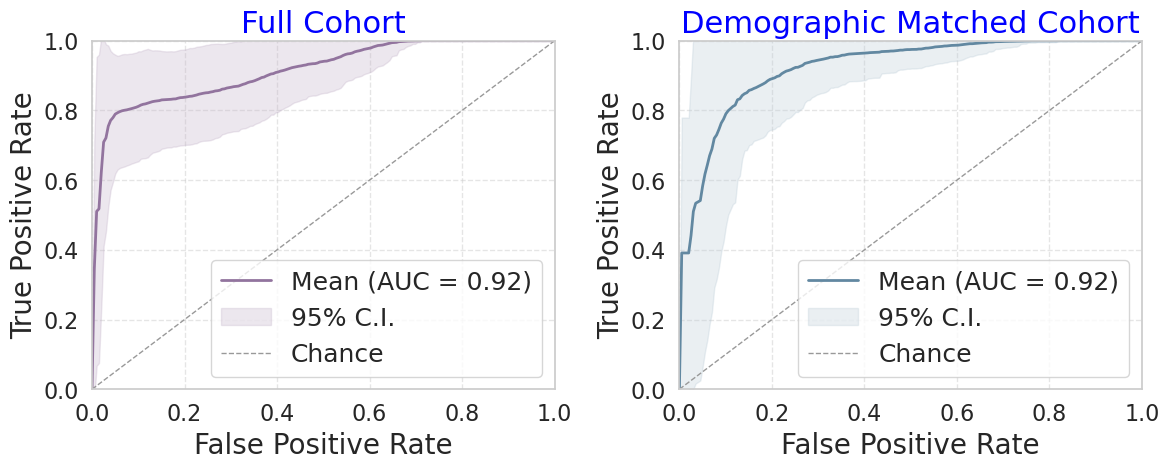

In [114]:
np.random.seed(0)
preds_list = [
    data_full_sample['pred_score_fusion'],
    data_demo_matched['pred_score_fusion'],
]
labels_list = [
    data_full_sample['true_label'],
    data_demo_matched['true_label'],
]
mean_colors = ["#92749e", "#6288a1", "#c9a88a"]
chance_colors = ["#999999"] * 3
ci_colors = ["#c2b1c8", "#bacbd6", "#decab8"]
titles = ["Full Cohort", "Demographic Matched Cohort"]

fig, axes = plot_multiple_rocs_with_ci(
    preds_list,
    labels_list,
    mean_colors,
    chance_colors,
    ci_colors,
    ci_alpha=0.3,
    n_bootstraps=300,
    seed=42,
    titles=titles,
    show_legend=True,  
    show_title=True    
)

plt.savefig("plots/figure_1/roc_curves.png", dpi=800, bbox_inches='tight')

plt.show()

In [115]:
def plot_prc_with_ci_ax(
    ax,
    preds,
    labels,
    n_bootstraps=1000,
    seed=None,
    mean_color="#1f77b4",
    chance_color="#7f7f7f",
    ci_color="#c7c7c7",
    ci_alpha=0.2,
    show_legend=True
):

    if seed is not None:
        np.random.seed(seed)

    # 1) Original PRC and average precision
    precision, recall, _ = precision_recall_curve(labels, preds)
    ap = average_precision_score(labels, preds)

    # 2) Bootstrap precision arrays on a fixed recall grid
    mean_recall = np.linspace(0, 1, 200)
    all_prec = []
    for _ in range(n_bootstraps):
        idxs = np.random.choice(len(preds), size=len(preds), replace=True)
        if len(np.unique(labels[idxs])) < 2:
            continue
        p_b, r_b, _ = precision_recall_curve(labels[idxs], preds[idxs])
        # sort r_b, p_b so interpolation is valid
        order = np.argsort(r_b)
        r_b, p_b = r_b[order], p_b[order]
        p_i = np.interp(mean_recall, r_b, p_b, left=p_b[0], right=p_b[-1])
        all_prec.append(p_i)
    all_prec = np.array(all_prec)
    b = all_prec.shape[0]

    # 3) Compute mean + SE → normal‐approx CI
    mean_prec = all_prec.mean(axis=0)
    se_prec   = np.sqrt(((all_prec - mean_prec)**2).sum(axis=0) / (b - 1))
    half_ci   = 1.96 * se_prec
    lower     = mean_prec - half_ci
    upper     = mean_prec + half_ci

    # 4) Plot mean curve + CI band + “chance” line
    ax.plot(mean_recall, mean_prec, color=mean_color, lw=2,
            label=f"Mean (MAP = {ap:.2f})")
    ax.fill_between(mean_recall, lower, upper,
                    color=ci_color, alpha=ci_alpha,
                    label=f"95% C.I.")
    # baseline = prevalence
    pos_rate = np.mean(labels)
    ax.hlines(pos_rate, 0, 1, linestyle='--',
              color=chance_color, lw=1, label="Chance")

    # 5) Formatting
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Recall", fontsize=20)
    ax.set_ylabel("Precision", fontsize=20)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)
    if show_legend:
        ax.legend(loc="lower left", fontsize=18)

def plot_multiple_prcs_with_ci(
    preds_list,
    labels_list,
    mean_colors,
    chance_colors,
    ci_colors,
    ci_alpha=0.2,
    n_bootstraps=1000,
    seed=None,
    titles=None,
    figsize=(12, 5),
    show_legend=True,
    show_title=True
):
    
    n = len(preds_list)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    
    for i, ax in enumerate(axes):
        plot_prc_with_ci_ax(
            ax,
            np.array(preds_list[i]),
            np.array(labels_list[i]),
            n_bootstraps=n_bootstraps,
            seed=seed,
            mean_color=mean_colors[i],
            chance_color=chance_colors[i],
            ci_color=ci_colors[i],
            ci_alpha=ci_alpha,
            show_legend=show_legend
        )
        if show_title and titles:
            ax.set_title(titles[i], fontsize=22, color='blue')
    plt.tight_layout()
    return fig, axes

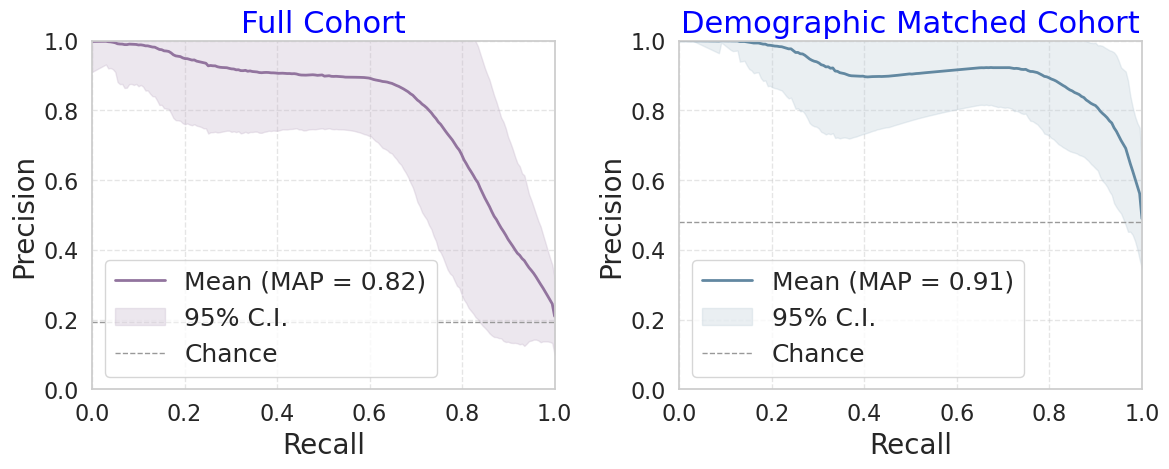

In [116]:
np.random.seed(0)
preds_list = [
    data_full_sample['pred_score_fusion'],
    data_demo_matched['pred_score_fusion']
]
labels_list = [
    data_full_sample['true_label'],
    data_demo_matched['true_label']
]

mean_colors   = ["#92749e", "#6288a1"]
chance_colors = ["#999999"] * 2
ci_colors     = ["#c2b1c8", "#bacbd6"]
titles        = ["Full Cohort", "Demographic Matched Cohort"]

fig, axes = plot_multiple_prcs_with_ci(
    preds_list,
    labels_list,
    mean_colors,
    chance_colors,
    ci_colors,
    ci_alpha=0.3,
    n_bootstraps=500,
    seed=42,
    titles=titles,
    show_legend=True,
    show_title=True
)

plt.savefig("plots/figure_1/pr_curves.png", dpi=800, bbox_inches='tight')
plt.show()

# Plot Calibration Curve

In [117]:
n_bins = 10

In [130]:
def calibration_curve(
    predictions,
    true_labels,
    n_bins=10,
    n_iterations=1000,
    random_state=None
):
    # np.random.seed(random_state)
    bins       = np.linspace(0, 1, n_bins + 1)
    bin_centers= (bins[:-1] + bins[1:]) / 2

    mean_props = []
    lower_ci   = []
    upper_ci   = []

    for i in range(n_bins):
        # Include right edge on last bin
        if i == n_bins - 1:
            in_bin = (predictions >= bins[i]) & (predictions <= bins[i+1])
        else:
            in_bin = (predictions >= bins[i]) & (predictions <  bins[i+1])

        labels_in_bin = true_labels[in_bin]
        if len(labels_in_bin) == 0:
            mean_props.append(np.nan)
            lower_ci.append(np.nan)
            upper_ci.append(np.nan)
            continue

        # Bootstrap the *labels* only
        props = []
        for _ in range(n_iterations):
            sample = resample(
                labels_in_bin,
                replace=True,
                n_samples=len(labels_in_bin),
                random_state=None   # allow true randomness
            )
            props.append(sample.mean())

        props = np.array(props)
        mu = props.mean()

        # # 3) Compute SE with denominator (b - 1)
        # b = len(props)
        # se = np.sqrt(np.sum((props - mu)**2) / (b - 1))

        # # 4) Normal‐approx 95% CI
        # lo = mu - 1.96 * se
        # hi = mu + 1.96 * se
        lo = np.percentile(props, q=2.5)
        hi = np.percentile(props, q=97.5)

        mean_props.append(mu)
        lower_ci.append(lo)
        upper_ci.append(hi)

    return (
      bin_centers,
      np.array(mean_props),
      np.array(lower_ci),
      np.array(upper_ci)
    )

In [131]:
import numpy as np
import matplotlib.pyplot as plt

def plot_calibration_curve_with_ci(
    bin_centers,
    mean_accuracies,
    lower_ci,
    upper_ci,
    ece,
    brier_score,
    cal_color: str = "#2E6930",         
    ci_color: str = "#FF0000",               
    ideal_color: str = "#4C72B0",       
    text_box_facecolor: str = "wheat",  
    text_box_alpha: float = 0.8,        
    figsize: tuple = (8, 6),            
    marker: str = "s"                   
):
    
    # default CI color to match calibration if not provided
    ci_color = ci_color or cal_color

    # 1) Drop empty bins
    mask = ~np.isnan(mean_accuracies)
    bc = bin_centers[mask]
    m  = mean_accuracies[mask]
    lo = lower_ci[mask]
    hi = upper_ci[mask]

    # 2) Build non‐negative error‐bar lengths
    yerr_lower = np.clip(m - lo, 0, None)
    yerr_upper = np.clip(hi - m, 0, None)

    # 3) Start figure
    plt.figure(figsize=figsize)

    # 4) Calibration curve with markers
    plt.plot(
        bc, m,
        marker=marker,
        color=cal_color,
        lw=2,
        label="Calibration curve"
    )

    # 5) Error bars
    plt.errorbar(
        bc, m,
        yerr=[yerr_lower, yerr_upper],
        fmt='none',
        ecolor=ci_color,
        lw=0.5,
        capsize=2,
        label="95% C.I."
    )

    # 6) Ideal diagonal
    plt.plot(
        [0, 1], [0, 1],
        linestyle='--',
        color=ideal_color,
        lw=1,
        label="Ideal calibration"
    )

    # 7) Labels, title, grid
    plt.xlabel('Predicted probability', fontsize=21)
    plt.ylabel('True probabilities in each bin', fontsize=21)
    #plt.title('Calibration Curve with Confidence Intervals')
    #plt.grid(True)

    # 8) Metrics textbox
    #textstr = f'Brier Score: {brier_score:.4f}\nECE: {ece:.4f}'
    textstr = f'Brier Score: {brier_score:.4f}'
    props = dict(boxstyle='round', facecolor=text_box_facecolor, alpha=text_box_alpha)
    plt.text(0.55, 0.05, textstr, fontsize=18, bbox=props)

    # 9) Axis limits & legend
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(loc='best', fontsize=18)
    # plt.savefig("plots/calibration_curve.png", dpi=800, bbox_inches='tight')
    plt.show()

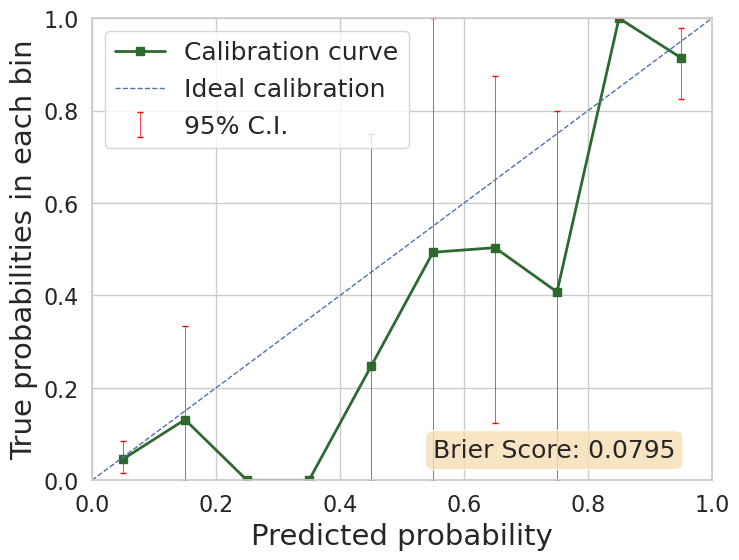

In [132]:
bin_centers, mean_acc, lo_ci, hi_ci = calibration_curve(
    data['pred_score_fusion'], data['true_label'],
    n_bins=n_bins,
    n_iterations=1000,
    random_state=42
)

m = compute_metrics(
    y_pred_scores=data['pred_score_fusion'],
    y_true=data['true_label'],
    n_bins=n_bins,
    n_bootstraps=1000,
    random_state=42
)


plot_calibration_curve_with_ci(
    bin_centers, mean_acc, lo_ci, hi_ci,
    ece=m['ECE'],
    brier_score=m['Brier Score']
)

In [141]:
bins = [0, 0.015, 0.03, 0.05, np.inf]
base_labels = ['0-0.015', '0.015-0.03', '0.03-0.05', '0.05+']

data['std_bin_raw'] = pd.cut(
    data['pred_std_fusion'],
    bins=bins,
    labels=base_labels,
    right=False
)

counts = data['std_bin_raw'].value_counts().reindex(base_labels, fill_value=0)

bin_label_map = {
    lab: f"{name} (n={counts[lab]})"
    for lab, name in zip(base_labels, ['Low', 'Moderate', 'Substantial', 'High'])
}

data['std_bin'] = data['std_bin_raw'].map(bin_label_map)

data['std_bin'].value_counts().sort_index()

std_bin
Low (n=146)           146
Moderate (n=38)        38
Substantial (n=31)     31
High (n=13)            13
Name: count, dtype: int64

In [142]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
from sklearn.utils import resample

def calculate_metrics_bootstrapped(true_labels, pred_labels, n_bootstraps=100):
    rng = np.random.RandomState(seed=42)

    # Convert to numpy arrays
    true_labels = np.array(true_labels)
    pred_labels = np.array(pred_labels)

    # Lists to store bootstrap results
    boot_auroc, boot_acc, boot_ppv, boot_npv, boot_sens, boot_spec, boot_f1 = [], [], [], [], [], [], []

    boot_count = 0
    while boot_count < n_bootstraps:
        # Sample indices with replacement
        indices = rng.choice(len(true_labels), size=len(true_labels), replace=True)
        
        # Sample labels
        y_true = true_labels[indices]
        y_pred = pred_labels[indices]

        try:
            auroc = roc_auc_score(y_true, y_pred)
        except ValueError:
            continue  # Retry this bootstrap

        acc = accuracy_score(y_true, y_pred)

        try:
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        except ValueError:
            continue  # Retry this bootstrap

        # Compute metrics safely
        ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        f1_score = 2 * (ppv * sensitivity) / (ppv + sensitivity) if (ppv + sensitivity) > 0 else np.nan

        if np.isnan([ppv, npv, sensitivity, specificity, f1_score]).any():
            continue  # Retry this bootstrap

        # Append to result lists
        boot_auroc.append(auroc)
        boot_acc.append(acc)
        boot_ppv.append(ppv)
        boot_npv.append(npv)
        boot_sens.append(sensitivity)
        boot_spec.append(specificity)
        boot_f1.append(f1_score)

        boot_count += 1  # only increment if the sample is valid

    # Aggregate results
    bootstrap_results = {
        'AUROC': boot_auroc,
        'Accuracy': boot_acc,
        'PPV': boot_ppv,
        'NPV': boot_npv,
        'Sensitivity': boot_sens,
        'Specificity': boot_spec,
        'F1 Score': boot_f1
    }

    # Summary with mean ± 95% CI
    summary = {}
    for metric, values in bootstrap_results.items():
        mean_val = np.nanmean(values)
        lower_ci = np.nanpercentile(values, 2.5)
        upper_ci = np.nanpercentile(values, 97.5)
        margin = (upper_ci - lower_ci) / 2
        summary[metric] = f"{round(mean_val * 100, 1)} ± {round(margin * 100, 1)}"

    summary_df = pd.DataFrame.from_dict(summary, orient='index', columns=['Mean ± 95% CI'])
    return summary_df, bootstrap_results


In [143]:
data['pred_park'] = data['pred_score_fusion'] >= 0.5

In [144]:
# now we can calculate metrics for each bin
results_by_std_bin = {}

labels = data['std_bin'].dropna().unique().sort_values()


for bin_label in labels:
    subset = data[data['std_bin'] == bin_label]
    true_labels = np.asarray(subset['true_label'])
    pred_labels = np.asarray(subset['pred_park'])

    # if len(true_labels) < 10:
    #     print(f"Skipping bin {bin_label} due to insufficient samples ({len(true_labels)} samples).")
    #     continue
    
    summary_df, bootstrap_results = calculate_metrics_bootstrapped(true_labels, pred_labels)
    results_by_std_bin[bin_label] = {
        'summary': summary_df,
        'bootstraps': bootstrap_results,
        'n_samples': len(true_labels)
    }
    
rows = []
for bin_label, result in results_by_std_bin.items():
    summary = result["summary"]  # index: metrics; col: "Mean ± 95% CI"
    for metric in summary.index:
        s = str(summary.loc[metric, "Mean ± 95% CI"])  # e.g., "83.4 ± 3.2" or "83.4% ± 3.2%"
        parts = [p.replace("%", "").strip() for p in s.split("±")]
        if len(parts) != 2:
            continue
        try:
            mean = float(parts[0]) / 100.0
            ci   = float(parts[1]) / 100.0
        except ValueError:
            continue
        rows.append({"Std Bin": bin_label, "Metric": metric, "Mean": mean, "CI": ci})

plot_df = pd.DataFrame(rows)

plot_df

,Std Bin,Metric,Mean,CI
0,Low (n=146),AUROC,0.930,0.059
1,Low (n=146),Accuracy,0.954,0.034
2,Low (n=146),PPV,0.916,0.094
3,Low (n=146),NPV,0.965,0.035
4,Low (n=146),Sensitivity,0.885,0.115
5,Low (n=146),Specificity,0.975,0.029
6,Low (n=146),F1 Score,0.899,0.086
7,Moderate (n=38),AUROC,0.913,0.096
8,Moderate (n=38),Accuracy,0.918,0.092
9,Moderate (n=38),PPV,0.938,0.097


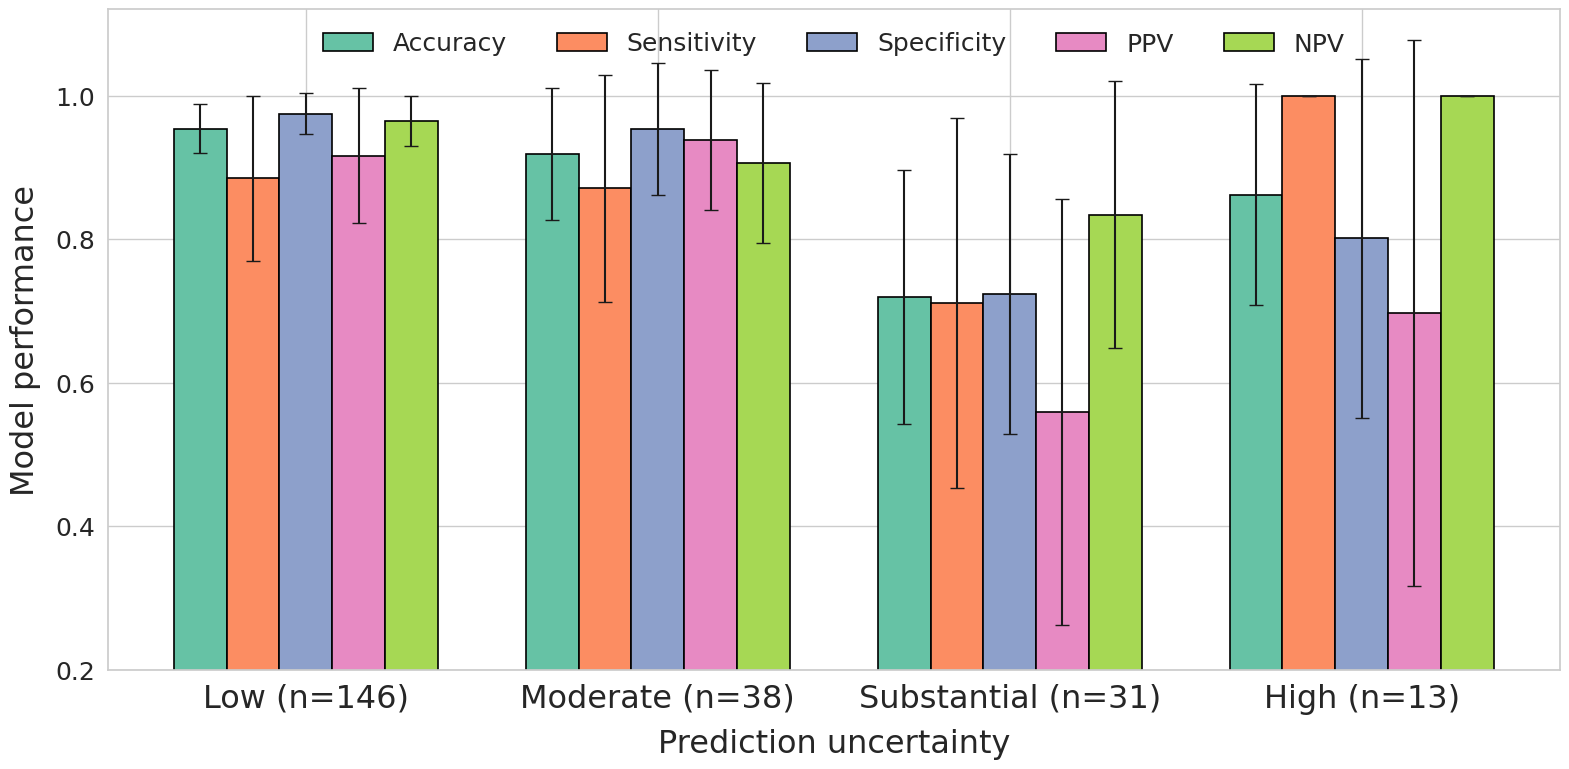

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Assuming plot_df already exists with columns ['Std Bin','Metric','Mean','CI'] ---

plt.figure(figsize=(16, 8))
sns.set(style="whitegrid", font_scale=1.4)  # scale base font sizes

metrics_to_plot = ['Accuracy', 'Sensitivity', 'Specificity', 'PPV', 'NPV']
bar_width = 0.15
x = np.arange(len(plot_df['Std Bin'].unique()))
# labels = plot_df['Std Bin'].unique()
labels = data['std_bin'].dropna().unique().sort_values()



# Assign consistent colors
colors = sns.color_palette("Set2", len(metrics_to_plot))

for i, metric in enumerate(metrics_to_plot):
    subset = plot_df[plot_df['Metric'] == metric]
    bars = plt.bar(
        x + i * bar_width,
        subset['Mean'],
        yerr=subset['CI'],
        width=bar_width,
        label=metric,
        capsize=5,
        color=colors[i],
        edgecolor="black",
        linewidth=1.2
    )
    # Add labels above upper CI
    # for j, (mean, ci) in enumerate(zip(subset['Mean'], subset['CI'])):
    #     top = mean + ci
    #     plt.text(
    #         x[j] + i * bar_width,
    #         top + 0.02,   # slightly larger offset
    #         f"{mean*100:.1f}%",
    #         ha='center', va='bottom',
    #         fontsize=14
    #     )

# Formatting
plt.ylim(0.2, 1.12)
plt.xlabel("Prediction uncertainty", fontsize=23, labelpad=10)
plt.ylabel("Model performance", fontsize=23, labelpad=10)
# plt.title("Model performance by prediction uncertainty", fontsize=18, weight="bold", pad=15)

plt.xticks(x + bar_width * (len(metrics_to_plot) - 1) / 2, labels, fontsize=23)
plt.yticks(fontsize=18)

plt.legend(
    # title="Performance Metrics",
    # bbox_to_anchor=(0.5, 1),
    loc="upper center",
    ncol=len(metrics_to_plot),
    frameon=False,
    fontsize=18,
    title_fontsize=14
)

plt.tight_layout()
# plt.savefig("plots/figure_1/uncertainty_metrics_bars_no_pct.png", dpi=600, bbox_inches="tight")
plt.show()


In [146]:
# we bucketize rows based on pred_score_fusion with 0.1 increments
# we calcualte the level of uncertainty in each bucket

data['score_bin'] = pd.cut(data['pred_score_fusion'], 
                                                bins=np.arange(0, 1.1, 0.1), 
                                                labels=[f"{i/10:.1f}-{(i+1)/10:.1f}" for i in range(10)],
                                                right=False)
data['score_bin'].value_counts().sort_index()

# check count of uncertainty level in each bucket
uncertainty_distribution = data.groupby(['score_bin', 'std_bin']).size().unstack(fill_value=0)
uncertainty_distribution

/tmp/ipykernel_2544004/2524502405.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  uncertainty_distribution = data.groupby(['score_bin', 'std_bin']).size().unstack(fill_value=0)


std_bin,Low (n=146),Moderate (n=38),Substantial (n=31),High (n=13)
score_bin,,,,
0.0-0.1,111,17,2,0
0.1-0.2,1,5,9,0
0.2-0.3,0,1,1,2
0.3-0.4,0,0,3,4
0.4-0.5,0,0,3,1
0.5-0.6,0,0,0,2
0.6-0.7,0,1,5,2
0.7-0.8,0,0,3,2
0.8-0.9,1,2,4,0


In [147]:
uncertainty_distribution.columns

CategoricalIndex(['Low (n=146)', 'Moderate (n=38)', 'Substantial (n=31)',
                  'High (n=13)'],
                 categories=['Low (n=146)', 'Moderate (n=38)', 'Substantial (n=31)', 'High (n=13)'], ordered=True, dtype='category', name='std_bin')

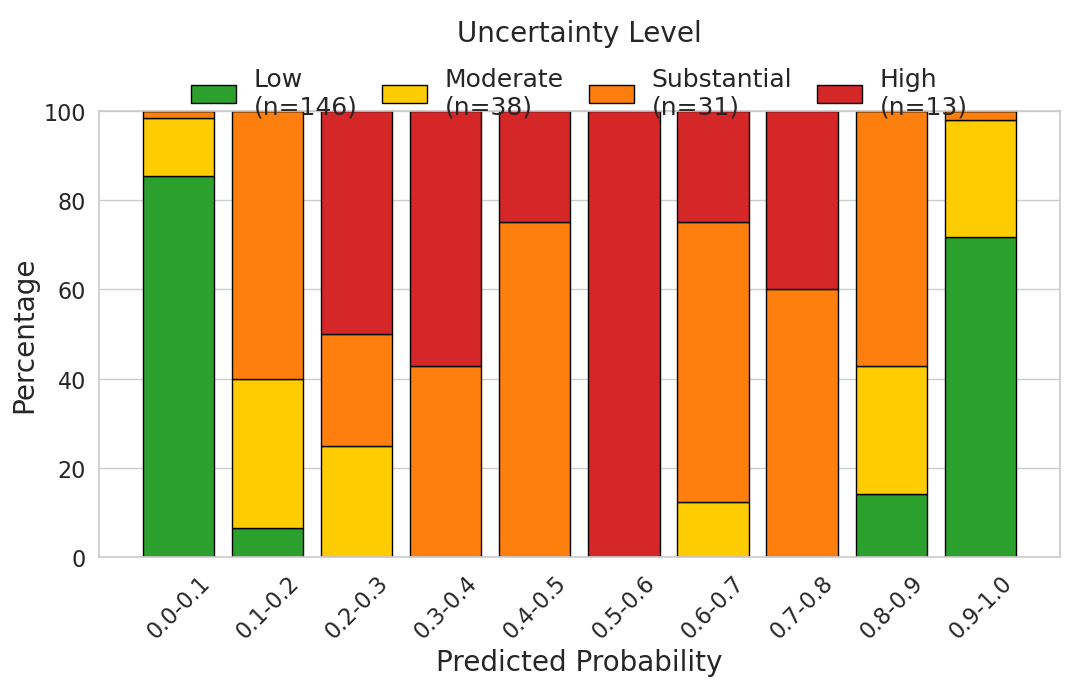

In [182]:
import pandas as pd
import matplotlib.pyplot as plt

# Data provided
data = {
    "score_bin": uncertainty_distribution.index.astype(str).tolist(),
    "Low": uncertainty_distribution.loc[:, [c for c in uncertainty_distribution.columns if c.startswith("Low (n=")][0]].values,
    "Moderate": uncertainty_distribution.loc[:, [c for c in uncertainty_distribution.columns if c.startswith("Moderate (n=")][0]].values,
    "Substantial": uncertainty_distribution.loc[:, [c for c in uncertainty_distribution.columns if c.startswith("Substantial (n=")][0]].values,
    "High": uncertainty_distribution.loc[:, [c for c in uncertainty_distribution.columns if c.startswith("High (n=")][0]].values
}


# Create DataFrame
df = pd.DataFrame(data)

# Normalize counts to percentages row-wise
df_percent = df.copy()
categories = ["Low", "Moderate", "Substantial", "High"]
df_percent[categories] = df_percent[categories].div(df_percent[categories].sum(axis=1), axis=0) * 100

# Colors with increasing intensity palette (green → yellow → orange → red)
colors = {
    "Low": "#2ca02c",  # medium green
    "Moderate": "#ffcc00",  # golden yellow
    "Substantial": "#ff7f0e",  # bright orange
    "High": "#d62728"  # strong red
}

# Build two-line legend labels
legend_label_map = {
    "Low": f"Low\n({uncertainty_distribution.columns[0].split('(')[1]}",
    "Moderate": f"Moderate\n({uncertainty_distribution.columns[1].split('(')[1]}",
    "Substantial": f"Substantial\n({uncertainty_distribution.columns[2].split('(')[1]}",
    "High": f"High\n({uncertainty_distribution.columns[3].split('(')[1]}"
}
# Plotting
fig, ax = plt.subplots(figsize=(11,7.5))

bottom = None
for category in categories:
    bars = ax.bar(df_percent["score_bin"], df_percent[category],
                  bottom=bottom, color=colors[category], edgecolor="black",
                  label=legend_label_map[category])
    # Add percentage labels inside segments if large enough
    # for bar, val in zip(bars, df_percent[category]):
    #     if val > 5:  # label only if >5%
    #         ax.text(bar.get_x() + bar.get_width()/2,
    #                 bar.get_y() + bar.get_height()/2,
    #                 f"{val:.0f}%", ha="center", va="center", fontsize=14, color="black")
    if bottom is None:
        bottom = df_percent[category].copy()
    else:
        bottom += df_percent[category]

# # Style
# ax.set_xlabel("Predicted Probability", fontsize=26)
# ax.set_ylabel("Percentage", fontsize=26)
# ax.set_ylim(0, 100)
# ax.set_xticklabels(df_percent["score_bin"], rotation=45, fontsize=23)
# ax.tick_params(axis="y", labelsize=23)
# ax.grid(axis="y", linestyle="--", alpha=0.7)

# # Legend above plot
# ax.legend(title="Uncertainty Level", fontsize=23, title_fontsize=26,
#           ncol=4, bbox_to_anchor=(0.5, 1.25), loc="upper center", frameon=False)

# # Remove title for cleaner look
# ax.set_title("")

# plt.tight_layout()

ax.set_xlabel("Predicted Probability", fontsize=20)
ax.set_ylabel("Percentage", fontsize=20)
ax.set_xticks(range(len(df_percent["score_bin"])))
ax.set_xticklabels(df_percent["score_bin"], rotation=45, fontsize=16)
ax.tick_params(axis="y", labelsize=16)

ax.legend(
    title="Uncertainty Level",
    fontsize=18,
    title_fontsize=20,
    ncol=4,
    bbox_to_anchor=(0.5, 1.25),
    loc="upper center",
    frameon=False,
    columnspacing=1.0,
    handletextpad=0.7,
    borderaxespad=0.4,
    handlelength=1.8,
    labelspacing=0.8
)

plt.tight_layout()

plt.savefig("plots/figure_1/uncertainty_distribution.png", dpi=600)
plt.show()


/tmp/ipykernel_2544004/486601627.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_percent["score_bin"], rotation=45, fontsize=23)


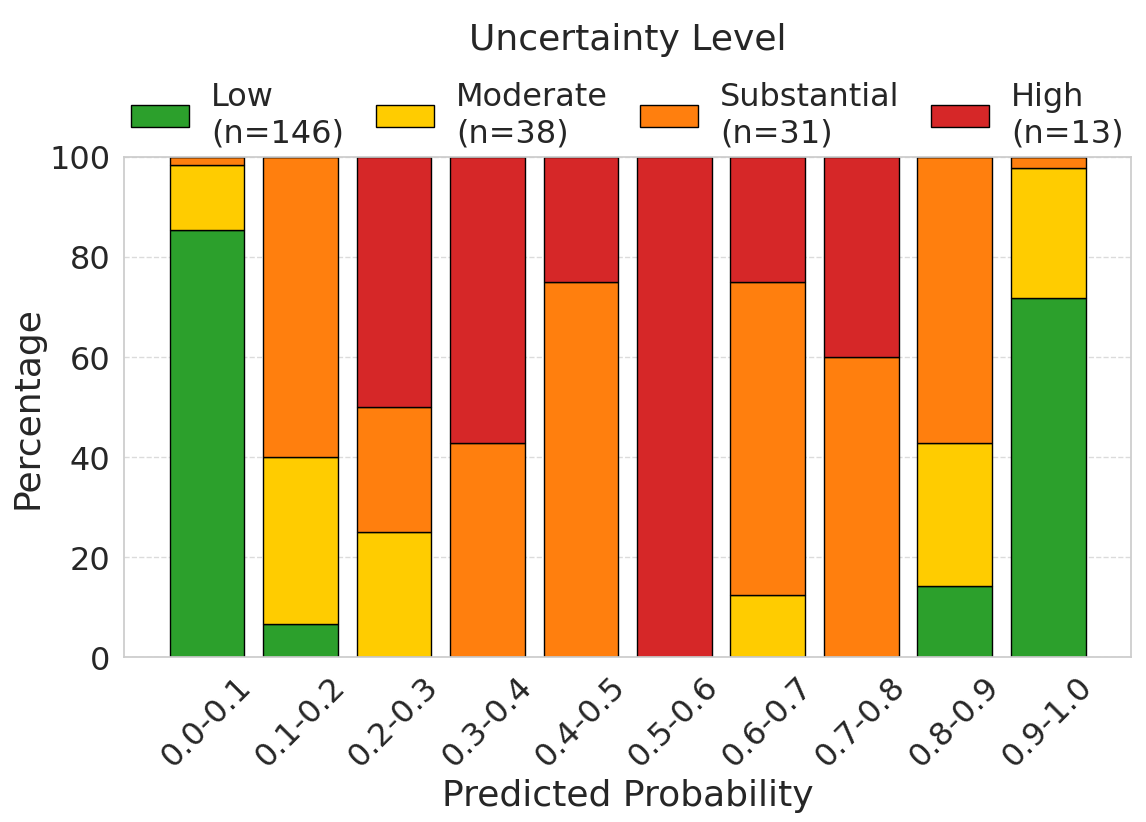

In [207]:
import pandas as pd
import matplotlib.pyplot as plt

# Data provided
data = {
    "score_bin": uncertainty_distribution.index.astype(str).tolist(),
    "Low": uncertainty_distribution.loc[:, [c for c in uncertainty_distribution.columns if c.startswith("Low (n=")][0]].values,
    "Moderate": uncertainty_distribution.loc[:, [c for c in uncertainty_distribution.columns if c.startswith("Moderate (n=")][0]].values,
    "Substantial": uncertainty_distribution.loc[:, [c for c in uncertainty_distribution.columns if c.startswith("Substantial (n=")][0]].values,
    "High": uncertainty_distribution.loc[:, [c for c in uncertainty_distribution.columns if c.startswith("High (n=")][0]].values
}


# Create DataFrame
df = pd.DataFrame(data)

# Normalize counts to percentages row-wise
df_percent = df.copy()
categories = ["Low", "Moderate", "Substantial", "High"]
df_percent[categories] = df_percent[categories].div(df_percent[categories].sum(axis=1), axis=0) * 100

# Colors with increasing intensity palette (green → yellow → orange → red)
colors = {
    "Low": "#2ca02c",  # medium green
    "Moderate": "#ffcc00",  # golden yellow
    "Substantial": "#ff7f0e",  # bright orange
    "High": "#d62728"  # strong red
}

# Build two-line legend labels
legend_label_map = {
    "Low": f"Low\n({uncertainty_distribution.columns[0].split('(')[1]}",
    "Moderate": f"Moderate\n({uncertainty_distribution.columns[1].split('(')[1]}",
    "Substantial": f"Substantial\n({uncertainty_distribution.columns[2].split('(')[1]}",
    "High": f"High\n({uncertainty_distribution.columns[3].split('(')[1]}"
}
# Plotting
fig, ax = plt.subplots(figsize=(13,6.5))

bottom = None
for category in categories:
    bars = ax.bar(df_percent["score_bin"], df_percent[category],
                  bottom=bottom, color=colors[category], edgecolor="black",
                  label=legend_label_map[category])
    if bottom is None:
        bottom = df_percent[category].copy()
    else:
        bottom += df_percent[category]

# Style
ax.set_xlabel("Predicted Probability", fontsize=26)
ax.set_ylabel("Percentage", fontsize=26)
ax.set_ylim(0, 100)
ax.set_xticklabels(df_percent["score_bin"], rotation=45, fontsize=23)
ax.tick_params(axis="y", labelsize=23)
ax.grid(axis="y", linestyle="--", alpha=0.7)


# Remove title for cleaner look
ax.set_title("")

ax.legend(
    title="Uncertainty Level",
    fontsize=23,
    title_fontsize=26,
    ncol=4,
    bbox_to_anchor=(0.5, 1.32),
    loc="upper center",
    frameon=False,
    columnspacing=1.0,
    handletextpad=0.7,
    borderaxespad=0.4,
    handlelength=1.8,
    labelspacing=0.8
)

# plt.tight_layout()

plt.savefig(
    "plots/figure_1/uncertainty_distribution.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.2
)

plt.show()


# Plot Missclassification

In [149]:
df_metadata = pd.read_csv("../../data/metadata_full_cohort.csv")
df_metadata

,Protocol,Participant_ID,Task,gender,age,race,pd,Diagnosis,carrier,gender_normalized,age_normalized,age_numeric,age_processed,race_normalized,env
0,SuperPD,NIHFT628PHTAY,ahhhh,female,70.0,White,no,0,0,Female,60 - 79,70.0,70.0,White,Clinic
1,SuperPD,NIHYM875FLXFF,ahhhh,female,73.0,White,no,0,0,Female,60 - 79,73.0,73.0,White,Clinic
2,SuperPD,NIHBV117HUCTC,ahhhh,female,60.0,White,no,0,0,Female,60 - 79,60.0,60.0,White,Clinic
3,SuperPD,NIHTN717JDEYY,eye_gaze,female,50.0,White,no,0,0,Female,40 - 59,50.0,50.0,White,Clinic
4,SuperPD,NIHHY970PYCFA,quick_brown_fox,female,69.0,White,no,0,0,Female,60 - 79,69.0,69.0,White,Clinic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
676,ValorPD,UWVRZ5jOPXTXdOaFsF5FJdzzgwL2,NaN,F,61.0,White,no,0,1,Female,60 - 79,61.0,61.0,White,Clinic
677,ValorPD,14GYE2DIFeRiie4h48KtjxOaijm1,NaN,F,29.0,White,no,0,1,Female,20 - 39,29.0,29.0,White,Clinic
678,ValorPD,oxQnpE2jM2PG2MNDQZMmzARYRlj1,NaN,F,36.0,White,no,0,1,Female,20 - 39,36.0,36.0,White,Clinic
679,ValorPD,rJG6ZYa8OASB3bxczHFNiQulmyi1,NaN,F,34.0,White,no,0,1,Female,20 - 39,34.0,34.0,White,Clinic


In [150]:
data_full_sample_with_metadata = pd.merge(
    data_full_sample,
    df_metadata,
    left_on="id",
    right_on="Participant_ID",
    how="inner"
)
data_full_sample_with_metadata.shape 

(155, 26)

In [151]:
data_full_sample_with_metadata["race_renormalized"] = (
    data_full_sample_with_metadata["race_normalized"]
    .fillna("Non-White")
    .apply(lambda x: "White" if x == "White" else "Non-White")
)

# now make age_normalized "Unknown" if "Not Mentioned"
data_full_sample_with_metadata["age_normalized"] = (
    data_full_sample_with_metadata["age_normalized"]
    .fillna("Unknown")
    .apply(lambda x: "Unknown" if x == "Not Mentioned" else x)
)

In [152]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def bootstrap_mean_ci(series: pd.Series, n_iterations: int = 1000):
    series = series.dropna().values
    props = []
    for _ in range(n_iterations):
        sample = np.random.choice(series, size=len(series), replace=True)
        props.append(sample.mean())

    props = np.array(props)
    mu = props.mean()
    se = np.sqrt(np.sum((props - mu)**2) / (len(props) - 1))
    ci = (mu - 1.96 * se, mu + 1.96 * se)
    return float(round(mu, 2)), float(round(se, 2)), (float(round(ci[0], 2)), float(round(ci[1], 2)))


def compute_misclassification_summary(df, group_cols, pred_col='pred_score_fusion', true_col='true_label', threshold=0.5):
    df = df.copy()
    df['pred_label'] = (df[pred_col] >= threshold).astype(int)
    df['misclassified'] = (df['pred_label'] != df[true_col]).astype(int)

    summary = {}
    for col in group_cols:
        groups = df[col].dropna().unique()
        group_stats = []
        for group in groups:
            group_df = df[df[col] == group]
            mu, se, (ci_lower, ci_upper) = bootstrap_mean_ci(group_df['misclassified'])
            group_stats.append({
                'group': group,
                'mean': mu,
                'se': se,
                'ci_lower': ci_lower,
                'ci_upper': ci_upper,
                'n_total': len(group_df),
                'n_wrong': int(group_df['misclassified'].sum())
            })
        # Overall stats (optional)
        mu, se, (ci_lower, ci_upper) = bootstrap_mean_ci(df['misclassified'])
        group_stats.append({
            'group': 'all',
            'mean': mu,
            'se': se,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'n_total': len(df),
            'n_wrong': int(df['misclassified'].sum())
        })
        summary[col] = group_stats
    return summary


def plot_group_summary(
    summary,
    y_scale=(0, 0.7),
    y_scale_name='Misclassification Rate',
    save=False,
    filename='groupwise_misclassification.png'
):
    dims = list(summary.keys())
    dim_names = [d.replace('_', ' ').title() for d in dims]

    # custom_colors = {
    #     'Female': '#bfd3c1',
    #     'Male': '#efc7c2',
    #     'Non-white': '#b388eb',
    #     'white': '#ceb3f2',
    #     'Unknown': '#ceb333',
    #     '20 - 39': '#FFF085',
    #     '40 - 59': '#FCB454',
    #     '60 - 79': '#FF9B17',
    #     '>= 80': '#A86523'
    # }

    custom_colors = {
        'Female': '#1f77b4',
        'Male': '#aec7e8',
        'Non-white': '#ffbb78',
        'white': '#ff7f0e',
        'Unknown': '#b35f00',
        '20 - 39': '#98df8a',
        '40 - 59': '#2ca02c',
        '60 - 79': '#1e7f1e',
        '>= 80': '#0f3b0f'
    }

    include_values = {
        'gender_normalized': ['Male', 'Female'],
        'age_normalized': ['20 - 39', '40 - 59', '60 - 79', '>= 80', 'Unknown'],
        'race_normalized': ['white', 'Non-white', 'Unknown']
    }

    subcats_list, values_list, errors_list, label_list, count_labels = [], [], [], [], []

    for d in dims:
        print(d)
        stats = summary[d]
        print(stats)
        allowed_groups = include_values.get(d, None)

        subs = [
            s for s in stats
            if s['group'] != 'all' and (allowed_groups is None or s['group'] in allowed_groups)
        ]

        if allowed_groups:
            subs = sorted(subs, key=lambda x: allowed_groups.index(x['group']))

        groups = [s['group'] for s in subs]
        subcats_list.append(groups)
        label_list.append(groups)

        vals = [s['mean'] for s in subs]
        errs = [(s['mean'] - s['ci_lower'], s['ci_upper'] - s['mean']) for s in subs]
        values_list.append(vals)
        errors_list.append(np.array(errs).T)

        # Build count labels as "wrong/total"
        count_labels.append([f"{s['n_wrong']}/{s['n_total']}" for s in subs])

    # Plotting
    fig, ax = plt.subplots(figsize=(8, 6))
    x_base = np.arange(len(dims))
    bar_width = 0.25

    positions = []
    for i, (subs, vals, errs, count_strs) in enumerate(zip(subcats_list, values_list, errors_list, count_labels)):
        n = len(subs)
        mid = (n - 1) / 2
        for j, (sub, val, count_text) in enumerate(zip(subs, vals, count_strs)):
            xpos = x_base[i] + (j - mid) * bar_width
            color = custom_colors.get(sub, '#999999')
            ax.bar(xpos, val, width=bar_width, color=color, zorder=1)
            ax.errorbar(xpos, val, yerr=[[errs[0][j]], [errs[1][j]]],
                        fmt='none', ecolor='black', capsize=5, zorder=2, label='95% C.I.')
            positions.append((xpos, sub))

            # Add count label above CI bar
            if i==1 and j==2:
                ax.text(
                    xpos, val + errs[1][j] + 0.05,
                    count_text,
                    ha='center', va='bottom',
                    fontsize=18,
                    bbox=dict(facecolor=color, alpha=0.2, boxstyle='round,pad=0.2', edgecolor='none')
                )
            else:
                ax.text(
                    xpos, val + errs[1][j] + 0.02,
                    count_text,
                    ha='center', va='bottom',
                    fontsize=18,
                    bbox=dict(facecolor=color, alpha=0.2, boxstyle='round,pad=0.2', edgecolor='none')
                )

    # X-labels under bars
    for xpos, label in positions:
        ax.text(
            xpos, 0,
            label,
            ha='center', va='top',
            rotation=20,
            fontsize=18,
            transform=ax.get_xaxis_transform()
        )

    ax.set_xticks(x_base)
    ax.set_xticklabels(dim_names, fontsize=18)
    ax.tick_params(axis='x', which='major', pad=50, top=False, bottom=False) 
    ax.set_xticklabels(['Sex', 'Age Group', 'Race'], fontweight='bold', fontsize=18)
    ax.tick_params(axis='y', labelsize=18)

    ax.set_ylim(y_scale)
    ax.set_xlabel('Demographic Subgroups', labelpad=20, fontsize=22)
    ax.set_ylabel(y_scale_name, fontsize=22)
    plt.tight_layout()

    if save:
        fig.savefig(filename, dpi=800, bbox_inches='tight')
    #plt.legend()
    plt.show()


{'gender_normalized': [{'group': 'Male', 'mean': 0.07, 'se': 0.03, 'ci_lower': 0.01, 'ci_upper': 0.14, 'n_total': 68, 'n_wrong': 5}, {'group': 'Female', 'mean': 0.07, 'se': 0.03, 'ci_lower': 0.02, 'ci_upper': 0.13, 'n_total': 87, 'n_wrong': 6}, {'group': 'all', 'mean': 0.07, 'se': 0.02, 'ci_lower': 0.03, 'ci_upper': 0.11, 'n_total': 155, 'n_wrong': 11}], 'age_normalized': [{'group': '60 - 79', 'mean': 0.02, 'se': 0.02, 'ci_lower': -0.01, 'ci_upper': 0.06, 'n_total': 80, 'n_wrong': 2}, {'group': '20 - 39', 'mean': 0.14, 'se': 0.07, 'ci_lower': -0.01, 'ci_upper': 0.28, 'n_total': 21, 'n_wrong': 3}, {'group': '40 - 59', 'mean': 0.09, 'se': 0.04, 'ci_lower': 0.0, 'ci_upper': 0.17, 'n_total': 44, 'n_wrong': 4}, {'group': 'Unknown', 'mean': 0.2, 'se': 0.13, 'ci_lower': -0.05, 'ci_upper': 0.45, 'n_total': 10, 'n_wrong': 2}, {'group': 'all', 'mean': 0.07, 'se': 0.02, 'ci_lower': 0.03, 'ci_upper': 0.11, 'n_total': 155, 'n_wrong': 11}], 'race_renormalized': [{'group': 'White', 'mean': 0.07, 'se'

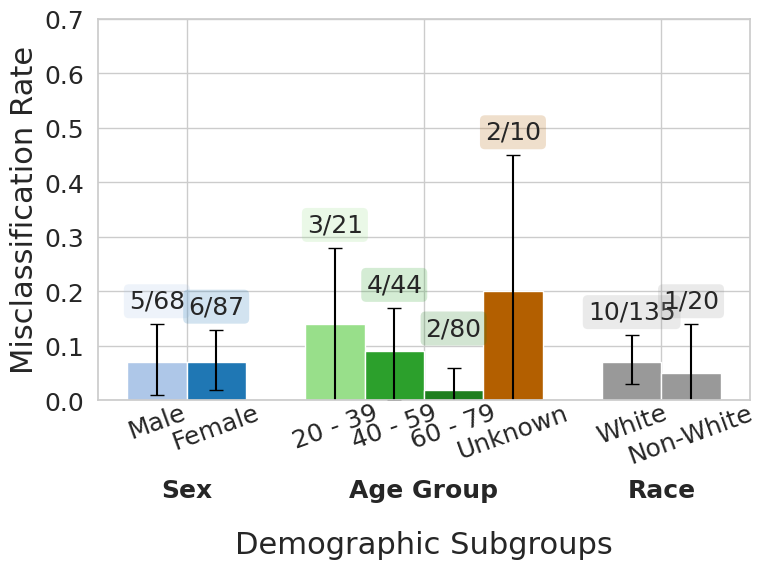

In [153]:
group_cols = ['gender_normalized', 'age_normalized', 'race_renormalized']
misclassification_summary = compute_misclassification_summary(data_full_sample_with_metadata, group_cols)
print(misclassification_summary)
plot_group_summary(misclassification_summary, save=True, filename='./plots/figure_1/groupwise_misclassification.png')

In [154]:
misclassification_summary

{'gender_normalized': [{'group': 'Male',
   'mean': 0.07,
   'se': 0.03,
   'ci_lower': 0.01,
   'ci_upper': 0.14,
   'n_total': 68,
   'n_wrong': 5},
  {'group': 'Female',
   'mean': 0.07,
   'se': 0.03,
   'ci_lower': 0.02,
   'ci_upper': 0.13,
   'n_total': 87,
   'n_wrong': 6},
  {'group': 'all',
   'mean': 0.07,
   'se': 0.02,
   'ci_lower': 0.03,
   'ci_upper': 0.11,
   'n_total': 155,
   'n_wrong': 11}],
 'age_normalized': [{'group': '60 - 79',
   'mean': 0.02,
   'se': 0.02,
   'ci_lower': -0.01,
   'ci_upper': 0.06,
   'n_total': 80,
   'n_wrong': 2},
  {'group': '20 - 39',
   'mean': 0.14,
   'se': 0.07,
   'ci_lower': -0.01,
   'ci_upper': 0.28,
   'n_total': 21,
   'n_wrong': 3},
  {'group': '40 - 59',
   'mean': 0.09,
   'se': 0.04,
   'ci_lower': 0.0,
   'ci_upper': 0.17,
   'n_total': 44,
   'n_wrong': 4},
  {'group': 'Unknown',
   'mean': 0.2,
   'se': 0.13,
   'ci_lower': -0.05,
   'ci_upper': 0.45,
   'n_total': 10,
   'n_wrong': 2},
  {'group': 'all',
   'mean': 0.07